<div style="text-align:center; background:#ffffff; padding:32px 20px; border:2px solid #d32f2f; border-radius:10px">
    <div style="font-size:46px; font-weight:bold; color:#000000; letter-spacing:4px; text-transform:uppercase">
        Sanghelios
    </div>
    <div style="font-size:17px; color:#000000; margin-top:10px; letter-spacing:3px; text-transform:uppercase">
        Parte 1 — EDA y Preprocesamiento
    </div>
    <div style="font-size:17px; color:#000000; margin-top:14px; letter-spacing:1px">
        Autores: Jose Miguel García Vélez & Jerónimo Hoyos Botero
    </div>
    <div style="font-size:17px; color:#000000; margin-top:6px; letter-spacing:1px">
        Creado: Mayo 2025 &nbsp;|&nbsp; Última actualización: Junio 2026
    </div>
</div>

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Configuración
</div>

**Ajustes del notebooks**

In [621]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Importaciones**

In [ ]:
# Standard library
import math
import re
import unicodedata

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno
from IPython.display import display

# Estadística y detección de outliers
from scipy.stats import zscore
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

# Utilidades del proyecto
from utils import *

print("Funciones personalizadas cargadas correctamente")

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Carga de Datos
</div>

In [ ]:
paths = {
    "banco_sangre": r"..\data\raw\banco_sangre.csv",
    "defunciones": r"..\data\raw\defunciones.csv",
    "atenciones": r"..\data\raw\atenciones.csv",
}

dataframes = cargar_csvs(paths)

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones = dataframes["defunciones"]
df_atenciones = dataframes["atenciones"]

print("\nDimensiones de los DataFrames:")
print("Banco de Sangre:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Atenciones:", df_atenciones.shape)

# Limpiar memoria
del dataframes

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
Preparacion Dataframe del Banco de Sangre
</div>

Preprocesamiento del DataFrame de bancos de sangre y creacion de serie temporal donaciones por dia.

| | |
|---|---|
| **Responsable** | Jerónimo Hoyos Botero |

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Vistazo de los datos
</div>

In [624]:
explorar_df(df_banco_sangre, "Banco de Sangre")


 Banco de Sangre  —  35,840 filas × 11 columnas
 Duplicados  1,622 (4.5%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
ANO,int64,,0,0.0,2020,2020,2020
TRIMESTRE,int64,,0,0.0,4,1,1
FECHA EXTRACCION,str,1335,0,0.0,28/12/2020,01/02/2020,01/02/2020
RH,str,8,41,0.1,0+,0+,0+
BARRIO,str,1274,7788,21.7,POPULAR 1,20 DE JULIO,20 DE JULIO
CIUDAD,str,28,0,0.0,MEDELLIN,MEDELLIN,MEDELLIN
EDAD,float64,,2,0.0,41.0,43.0,43.0
ESTATURA,float64,,79,0.2,NaN,1.74,1.74
FECHA NACIMIENTO,str,13393,2,0.0,1982 Jan 01 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Mar 12 12:00:00 AM
PESO,float64,,41,0.1,NaN,80.0,80.0


In [625]:
df_banco_sangre.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
ANO,2021.828599,1.569845,2020.0,2021.0,2022.00,2023.00,2025.00
TRIMESTRE,2.387249,1.118653,1.0,1.0,2.00,3.00,4.00
EDAD,37.713070,12.497798,14.0,27.0,36.00,47.00,104.00
ESTATURA,1.663522,0.089134,1.0,1.6,1.66,1.73,2.03
PESO,73.329004,13.517872,50.0,63.0,72.00,81.00,171.00


**Observaciones:**

- No se encontró variables con un >40% de datos nulos
- Se encontraron variables irrelevantes como "fecha nacimiento"
- Todas las variables categoricas contiene almenos 2 subniveles
- No se visualizan desviaciones estándar "muy bajas" dado el contexto de cada variable 
- Se encontraron 1622 filas duplicadas, equivalente a un 4.5% de todas las filas

Se realizará una estandarización de nombres de las variables y selección de columnas relevantes.

In [626]:
df_banco_sangre = estandarizar_columnas(df_banco_sangre)

  'ANO'                               → 'ano'
  'TRIMESTRE'                         → 'trimestre'
  'FECHA EXTRACCION'                  → 'fecha_extraccion'
  'RH'                                → 'rh'
  'BARRIO'                            → 'barrio'
  'CIUDAD'                            → 'ciudad'
  'EDAD'                              → 'edad'
  'ESTATURA'                          → 'estatura'
  'FECHA NACIMIENTO'                  → 'fecha_nacimiento'
  'PESO'                              → 'peso'
  'SEXO'                              → 'sexo'


In [627]:
columnas_originales_seleccionadas = [
    "fecha_extraccion",
    "rh",
    "barrio",
    "ciudad",
    "edad",
    "estatura",
    "peso",
    "sexo",
]

df_banco_sangre = df_banco_sangre[columnas_originales_seleccionadas]

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Tratamiento de filas repetidas
</div>

In [628]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df_banco_sangre.shape}')
df_banco_sangre.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df_banco_sangre.shape}')

Tamaño del set antes de eliminar las filas repetidas: (35840, 8)
Tamaño del set después de eliminar las filas repetidas: (34216, 8)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Análisis Datos Faltantes
</div>

In [629]:
total = len(df_banco_sangre)
missing = df_banco_sangre.isna().sum()

pd.DataFrame({"Faltantes": missing, "%": (missing / total * 100).round(1)}).sort_values(
    "Faltantes", ascending=False
)

,Faltantes,%
barrio,7703,22.5
estatura,78,0.2
rh,41,0.1
peso,39,0.1
edad,2,0.0
sexo,1,0.0
ciudad,0,0.0
fecha_extraccion,0,0.0


<Axes: >

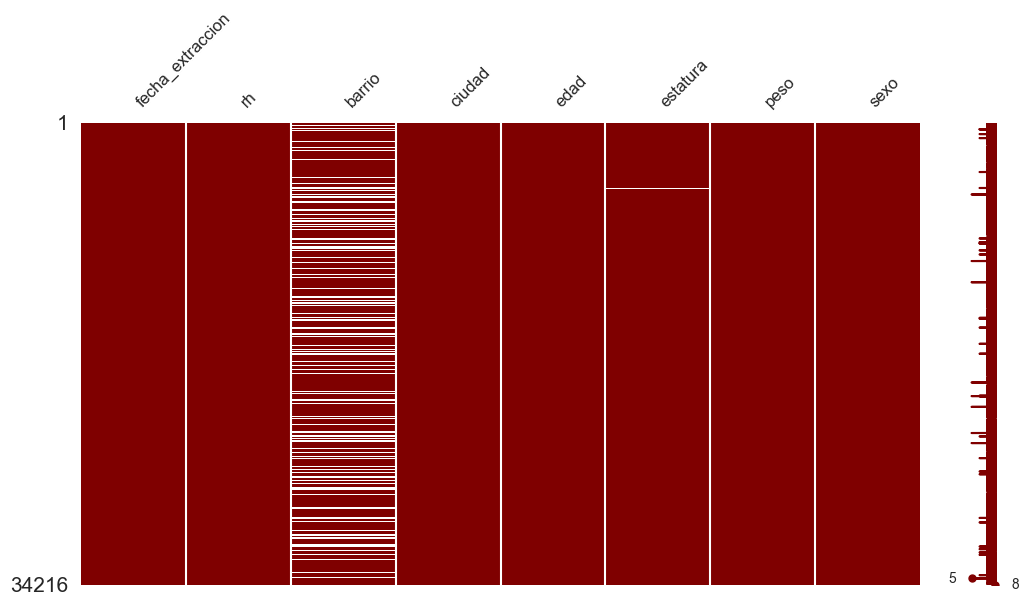

In [630]:
sorted_df = df_banco_sangre.sort_values("fecha_extraccion")
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

**Observaciones:**
- Las variables con datos faltantes tienen una proporción excluyendo la variable "barrio"
- La variable barrio tiene 7703, equivalente a un 22% de los datos.
- No se encontró un patrón claro del origen de los datos faltantes en "barrio"

> Se decide hacer una eliminación de todos los datos faltantes

In [631]:
print(f'Tamaño del set antes de eliminar las filas con valores faltantes: {df_banco_sangre.shape}')
df_banco_sangre = df_banco_sangre.dropna(subset=["rh", "estatura","barrio"])
print(f'Tamaño del set después de eliminar las filas con valores faltantes: {df_banco_sangre.shape}')

Tamaño del set antes de eliminar las filas con valores faltantes: (34216, 8)
Tamaño del set después de eliminar las filas con valores faltantes: (26412, 8)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Análisis de Datos Atípicos
</div>

Los requisitos para donar sangre según la [Cruz Roja Colombiana](https://www.cruzrojacolombiana.org/banco-de-sangre/dona-sangre) son:
- Pesar más de 50 kg
- Edad entre 18 y 65 años

Por lo tanto se hace el filtrado

In [632]:
print(f'Tamaño del set antes del filtrado: {df_banco_sangre.shape}')
df_banco_sangre = df_banco_sangre[
    (df_banco_sangre["peso"] > 50)
    & (df_banco_sangre["edad"] >= 18)
    & (df_banco_sangre["edad"] <= 65)
]
print(f'Tamaño del set después del filtrado: {df_banco_sangre.shape}')

Tamaño del set antes del filtrado: (26412, 8)
Tamaño del set después del filtrado: (26267, 8)


Revisión de datos atipicos univariados

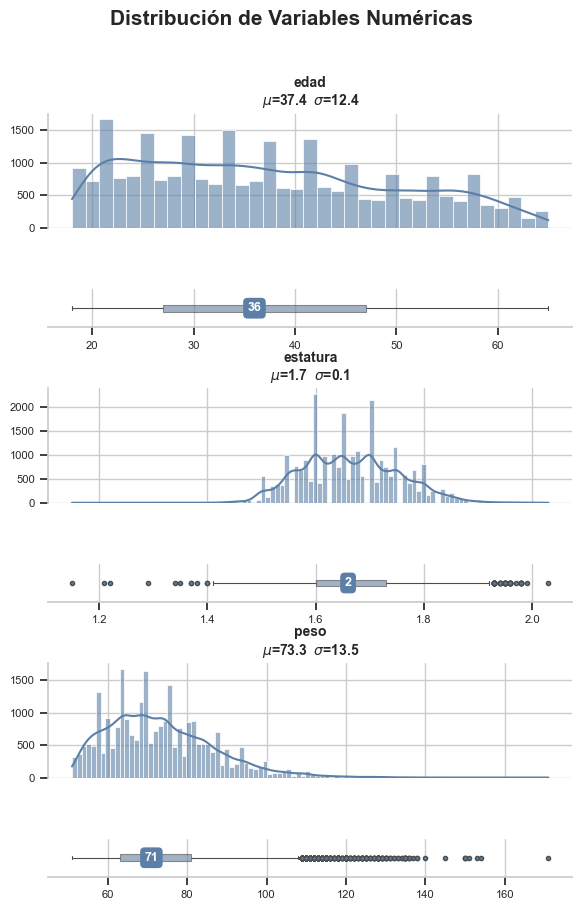

In [633]:
distribucion_numericas(df=df_banco_sangre, columnas=["edad", "estatura", "peso"],cols=1,modo="ambos",alto=3)

In [634]:
# IQR
print("\nIQR")
for col in ["edad", "peso", "estatura"]:
    Q1 = df_banco_sangre[col].quantile(0.25)
    Q3 = df_banco_sangre[col].quantile(0.75)
    IQR = Q3 - Q1
    n = (
        (df_banco_sangre[col] < Q1 - 1.5 * IQR)
        | (df_banco_sangre[col] > Q3 + 1.5 * IQR)
    ).sum()
    print(f"  {col}: {n} outliers")
    
# Z-score clásico
print("Z-score clásico")
for col in ["edad", "peso", "estatura"]:
    z = np.abs(zscore(df_banco_sangre[col].dropna()))
    print(f"  {col}: {(z > 3).sum()} outliers")

# Z-score modificado
print("\nZ-score modificado")
for col in ["edad", "peso", "estatura"]:
    mad = MAD(threshold=3.5)
    labels = mad.fit(df_banco_sangre[col].dropna().values.reshape(-1, 1)).labels_
    print(f"  {col}: {labels.sum()} outliers")


IQR
  edad: 0 outliers
  peso: 427 outliers
  estatura: 61 outliers
Z-score clásico
  edad: 0 outliers
  peso: 238 outliers
  estatura: 43 outliers

Z-score modificado
  edad: 0 outliers
  peso: 159 outliers
  estatura: 14 outliers


**Observaciones:**
- No se encontraron datos átipicos en la variable "edad" pero en "peso" y "estatura" sí se encontaron
- Se encuentra que "estatura" es bastante simetrica
- Se encuentra que "peso" con un sesgo negativo
> Se decide eliminar los datos atípicos de estatura con "Z-Score" y los "peso" con "Z-score modificado"

In [635]:
print(f'Tamaño del set antes de datos atípicos univariados: {df_banco_sangre.shape}')

z_edad = np.abs((df_banco_sangre["edad"] - df_banco_sangre["edad"].mean()) / df_banco_sangre["edad"].std())
outliers_edad = df_banco_sangre[z_edad > 3].index

peso_med = df_banco_sangre["peso"].median()
mad_peso = (df_banco_sangre["peso"] - peso_med).abs().median() or 1e-6
z_peso = (0.6745 * (df_banco_sangre["peso"] - peso_med).abs()) / mad_peso
outliers_peso = df_banco_sangre[z_peso > 3.5].index

df_banco_sangre = df_banco_sangre.drop(index=outliers_edad.union(outliers_peso))

print(f'Tamaño del set después de datos atípicos univariados: {df_banco_sangre.shape}')


Tamaño del set antes de datos atípicos univariados: (26267, 8)
Tamaño del set después de datos atípicos univariados: (26108, 8)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Manejo de errores tipográficos en variables categóricos
</div>

**Ajuste de formatos**

In [636]:
df_banco_sangre.dtypes

fecha_extraccion        str
rh                      str
barrio                  str
ciudad                  str
edad                float64
estatura            float64
peso                float64
sexo                    str
dtype: object

In [637]:
# Aplicar un formato estandarizado a la fecha y convertir edad a entero

df_banco_sangre["fecha_extraccion"] = pd.to_datetime(df_banco_sangre["fecha_extraccion"], format="%d/%m/%Y").dt.date
df_banco_sangre['fecha_extraccion'] = pd.to_datetime(df_banco_sangre['fecha_extraccion'])

df_banco_sangre["edad"] = df_banco_sangre["edad"].astype(int)

**Estandarización de variables categoricas**

In [638]:
# Define categorical columns to standardize labels
columnas_para_estandarizar = ["barrio", "ciudad", "sexo"]

# Apply standardization of categorical labels
for column in columnas_para_estandarizar:
    df_banco_sangre[column] = df_banco_sangre[column].apply(estandarizar_etiquetas)

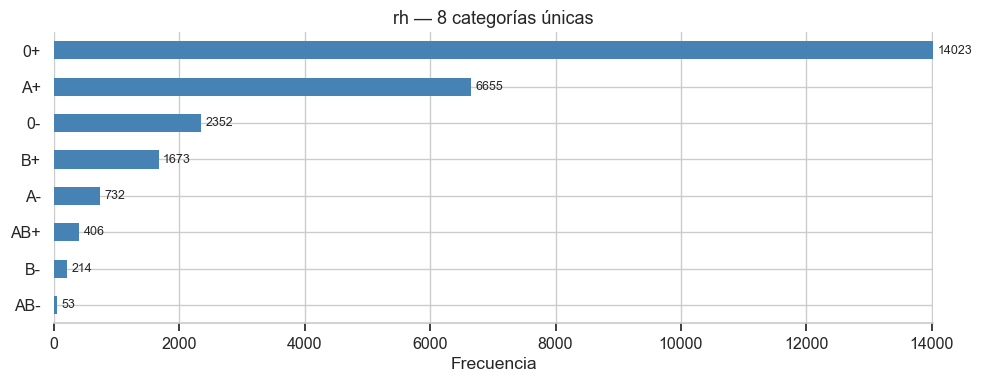

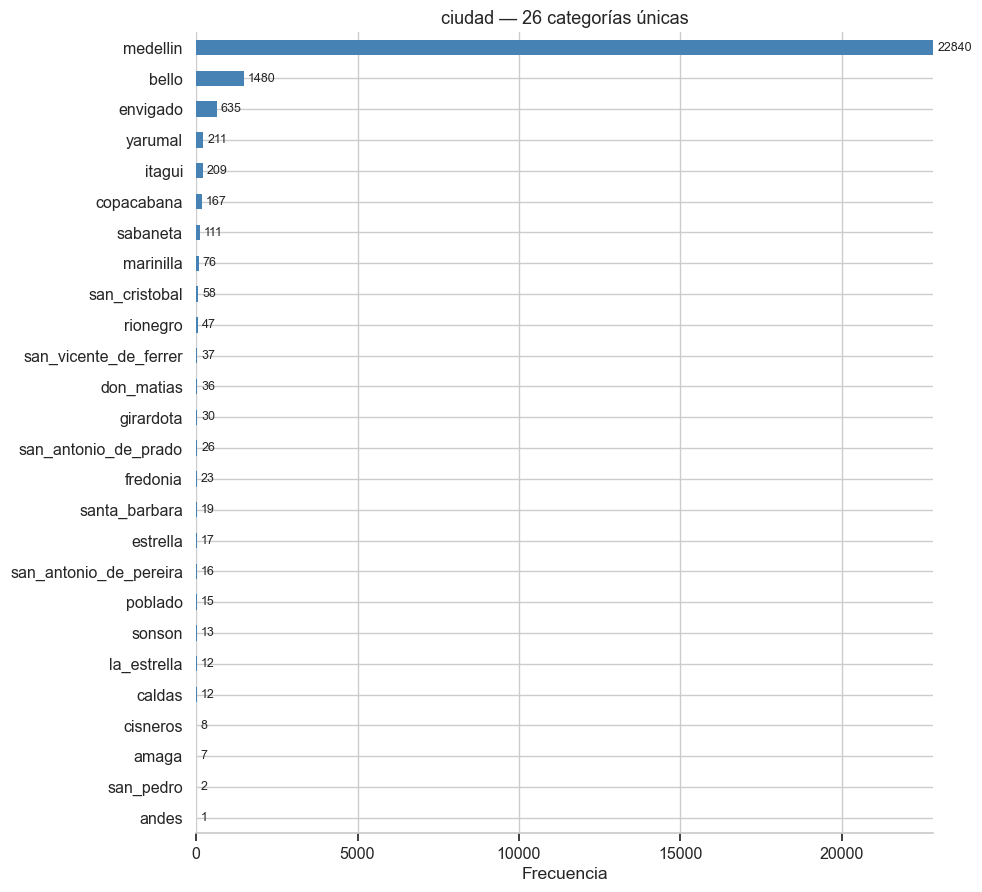

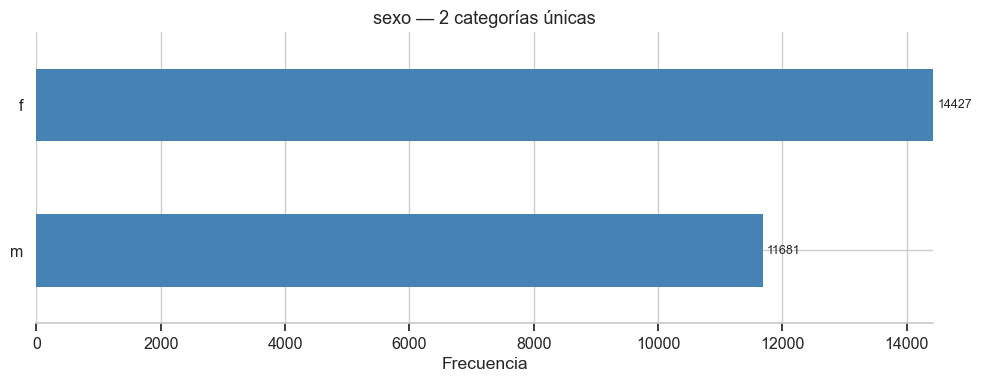

In [639]:
cols_cat = ["rh", "ciudad", "sexo"]

for col in cols_cat:
    conteo = df_banco_sangre[col].value_counts().sort_values(ascending=True)
    n = len(conteo)

    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.35)))
    conteo.plot(kind="barh", ax=ax, color="steelblue")

    ax.set_title(f"{col} — {n} categorías únicas", fontsize=13)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)

    ax.margins(0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)

    plt.tight_layout()
    plt.show()

**Observaciones**
- No se encontraron problemas tipograficos

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Ingeniería de Características 
</div>

Se creará la variable **cobertura**, que representa el porcentaje de la población que puede recibir sangre de un donante según su tipo sanguíneo y las reglas de compatibilidad ABO/Rh. Los porcentajes de distribución poblacional provienen del estudio [Ramírez-González et al. (2014)](https://dialnet.unirioja.es/descarga/articulo/8741610.pdf), realizado con 87.481 donantes del Hospital Pablo Tobón Uribe de Medellín entre 2000 y 2009.

In [640]:
# Distribución poblacional colombiana
dist_poblacion = {
    "0+": 52.1,
    "A+": 28.0,
    "B+": 7.0,
    "0-": 6.7,
    "A-": 3.5,
    "B-": 1.7,
    "AB+": 0.8,
    "AB-": 0.3,
}

# Cobertura: % de población que puede recibir cada tipo
cobertura_map = {
    "0-": 100.0,  # ← dona a todos, simplemente es 100%
    "0+": sum([dist_poblacion[k] for k in ["0+", "A+", "B+", "AB+"]]),
    "A-": sum([dist_poblacion[k] for k in ["A+", "A-", "AB+", "AB-"]]),
    "A+": sum([dist_poblacion[k] for k in ["A+", "AB+"]]),
    "B-": sum([dist_poblacion[k] for k in ["B+", "B-", "AB+", "AB-"]]),
    "B+": sum([dist_poblacion[k] for k in ["B+", "AB+"]]),
    "AB-": sum([dist_poblacion[k] for k in ["AB+", "AB-"]]),
    "AB+": sum([dist_poblacion[k] for k in ["AB+"]]),
}

# Agregamos ambas columnas al DataFrame basándonos en el 'rh'
df_banco_sangre["cobertura"] = df_banco_sangre["rh"].map(cobertura_map)
df_banco_sangre["pct_poblacion"] = df_banco_sangre["rh"].map(dist_poblacion)

# Agrupamos para obtener los valores únicos por cada RH presente en tu DataFrame
resultado = (
    df_banco_sangre.groupby("rh")[["pct_poblacion", "cobertura"]]
    .first()
    .sort_values("pct_poblacion", ascending=False)
)

print(f"{'RH':<5} | {'% Población Col.':<16} | {'% Cobertura':<26}")
print("-" * 55)
for sangre, filas in resultado.iterrows():
    print(
        f"{sangre:<5} | {filas['pct_poblacion']:>14.1f}% | {filas['cobertura']:>23.1f}%"
    )

RH    | % Población Col. | % Cobertura               
-------------------------------------------------------
0+    |           52.1% |                    87.9%
A+    |           28.0% |                    28.8%
B+    |            7.0% |                     7.8%
0-    |            6.7% |                   100.0%
A-    |            3.5% |                    32.6%
B-    |            1.7% |                     9.8%
AB+   |            0.8% |                     0.8%
AB-   |            0.3% |                     1.1%


Se creará la variable **imc** a partir del peso y la estatura del donante, reemplazando ambas variables por un único indicador clínico.

In [641]:
# Calcular IMC
df_banco_sangre["imc"] = (
    df_banco_sangre["peso"] / (df_banco_sangre["estatura"] ** 2)
).round(2)

# Eliminar estatura
df_banco_sangre = df_banco_sangre.drop(columns=["estatura", "peso"])

Se creará la variable **comuna** únicamente para los donantes de Medellín, asignando **no_aplica** al resto de municipios dado que no comparten el mismo esquema de división territorial.


In [642]:
from utils.barrios import *

df_banco_sangre["comuna_o_municipio"] = df_banco_sangre["barrio"].apply(get_comuna)
df_banco_sangre["comuna_o_municipio"].value_counts()

comuna_o_municipio
Bello                        3125
16 - Belén                   2069
7 - Robledo                  1843
Envigado                     1619
Itagüí                       1455
14 - El Poblado              1454
11 - Laureles-Estadio        1290
12 - La América              1109
9 - Buenos Aires             1087
3 - Manrique                 1073
5 - Castilla                 1040
4 - Aranjuez                  917
13 - San Javier               894
10 - La Candelaria            720
6 - Doce de Octubre           716
8 - Villa Hermosa             699
2 - Santa Cruz                661
1 - Popular                   586
15 - Guayabal                 521
desconocido                   440
Sabaneta                      424
60 - San Cristóbal            384
Caldas                        368
80 - San Antonio de Prado     327
Copacabana                    292
La Estrella                   243
90 - Santa Elena              230
70 - Altavista                223
Yarumal                      

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Resultado Limpieza
</div>

In [643]:
explorar_df(df_banco_sangre, "Banco de Sangre procesadas")


 Banco de Sangre procesadas  —  26,108 filas × 10 columnas
 Duplicados  0 (0.0%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
fecha_extraccion,datetime64[s],,0,0.0,2020-02-01 00:00:00,2020-02-01 00:00:00,2020-02-01 00:00:00
rh,str,8,0,0.0,0+,0+,0-
barrio,str,1268,0,0.0,20_de_julio,20_de_julio,cataluna
ciudad,str,26,0,0.0,medellin,medellin,medellin
edad,int64,,0,0.0,43,44,58
sexo,str,2,0,0.0,m,f,f
cobertura,float64,,0,0.0,87.9,87.9,100.0
pct_poblacion,float64,,0,0.0,52.1,52.1,6.7
imc,float64,,0,0.0,26.42,33.59,29.39
comuna_o_municipio,str,45,0,0.0,13 - San Javier,13 - San Javier,9 - Buenos Aires


In [644]:
df_banco_sangre.to_csv("../data/processed/df_banco_sangre_preprocessed.csv", index=False)

In [645]:
df_banco_sangre_time = df_banco_sangre.groupby(df_banco_sangre['fecha_extraccion'].dt.date).size().reset_index(name='donaciones_diarias')
df_banco_sangre_time.to_csv("../data/processed/df_banco_sangre_times_series.csv", index=False)

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
Preparacion Dataframe de Atenciones
</div>


Preprocesamiento del DataFrame de atenciones y creacion de serie temporal atenciones por dia.

| | |
|---|---|
| **Responsable 1** | Jose Miguel García Vélez|
| **Responsable 2** | Jerónimo Hoyos Botero|

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Vistazo a los datos
</div>

In [646]:
explorar_df(df_atenciones,"Atenciones")


 Atenciones  —  221,203 filas × 12 columnas
 Duplicados  9,626 (4.4%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
AÑO,int64,,0,0.0,2022,2022,2022
Periodo de reporte,int64,,0,0.0,1,1,1
Fecha atencion,str,1274,0,0.0,02/01/2022,02/01/2022,02/01/2022
servicio,str,4,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio
Sexo,str,3,5,0.0,M,M,M
Cod. Aseguradora,float64,,4972,2.2,20002686.0,20000362.0,20000368.0
Aseguradora,str,285,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA
Poblacion,str,6481,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ
Departamento,str,33,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,,0,0.0,2,35,24


In [647]:
df_atenciones = estandarizar_columnas(df_atenciones)

  'AÑO'                               → 'ano'
  'Periodo de reporte'                → 'periodo_de_reporte'
  'Fecha atencion'                    → 'fecha_atencion'
  'Sexo'                              → 'sexo'
  'Cod. Aseguradora'                  → 'cod_aseguradora'
  'Aseguradora'                       → 'aseguradora'
  'Poblacion'                         → 'poblacion'
  'Departamento'                      → 'departamento'
  'rango de edad'                     → 'rango_de_edad'


In [648]:
irrelevantes = ["ano",
                "periodo_de_reporte",
                "cod_aseguradora",
                "aseguradora",
                "poblacion",
                "departamento",
                "rango_de_edad",
                "regimen"
                ]

df_atenciones.drop(columns=irrelevantes, inplace=True)

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Tratamiento filas repetidas
</div>

In [649]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df_atenciones.shape}')
df_atenciones.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df_atenciones.shape}')

Tamaño del set antes de eliminar las filas repetidas: (221203, 4)
Tamaño del set después de eliminar las filas repetidas: (125977, 4)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Análisis Datos Faltantes
</div>

In [650]:
total = len(df_atenciones)
missing = df_atenciones.isna().sum()

pd.DataFrame({"Faltantes": missing, "%": (missing / total * 100).round(1)}).sort_values(
    "Faltantes", ascending=False
)

,Faltantes,%
sexo,5,0.0
fecha_atencion,0,0.0
servicio,0,0.0
edad,0,0.0


In [651]:
df_atenciones.dropna(inplace=True)

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Análisis de Datos Atípicos
</div>

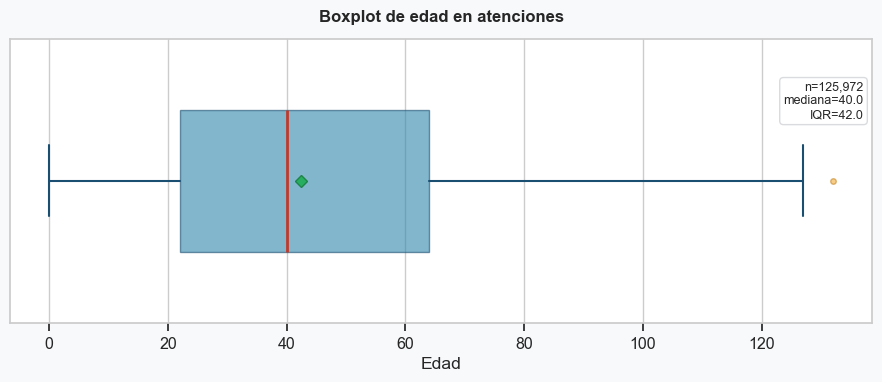

In [652]:
# Boxplot edad (estandarizado)
set_plot_style()
boxplot_pro(df_atenciones["edad"], title="Boxplot de edad en atenciones", xlabel="Edad")

In [653]:
# Ver edades mayores a 120 años
print("\nAtenciones con edad > 120 años:")
print(df_atenciones[df_atenciones["edad"] > 120][["edad", "fecha_atencion"]])

# La edad mas alta registrada en la historia es de 122 años, por lo que estos datos atipicos podrían ser errores de digitación o registros incorrectos. Procedemos a elimirlos.

df_atenciones = df_atenciones[df_atenciones["edad"] <= 120]

# Rango de edades
print("\nRango de edades en atenciones:")
print(f"Edad mínima: {df_atenciones['edad'].min()}")
print(f"Edad máxima: {df_atenciones['edad'].max()}")


Atenciones con edad > 120 años:
        edad fecha_atencion
201987   132     19/12/2025
212636   127     10/03/2026

Rango de edades en atenciones:
Edad mínima: 0
Edad máxima: 104


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Manejo de errores tipográficos en variables categóricos
</div>

In [654]:
df_atenciones.dtypes

fecha_atencion      str
servicio            str
sexo                str
edad              int64
dtype: object

In [655]:
# Define categorical columns to standardize labels
columnas_para_estandarizar = ["servicio", "sexo"]

# Apply standardization of categorical labels
for index in columnas_para_estandarizar:
    df_atenciones[index] = df_atenciones[index].apply(estandarizar_etiquetas)

In [656]:
df_atenciones["fecha_atencion"] = pd.to_datetime(df_atenciones["fecha_atencion"], format="%d/%m/%Y").dt.date
df_atenciones['fecha_atencion'] = pd.to_datetime(df_atenciones['fecha_atencion'])

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Resultados de la limpieza
</div>

In [657]:
explorar_df(df_atenciones,"Atenciones procesadas")


 Atenciones procesadas  —  125,970 filas × 4 columnas
 Duplicados  0 (0.0%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
fecha_atencion,datetime64[s],,0,0.0,2022-01-02 00:00:00,2022-01-02 00:00:00,2022-01-02 00:00:00
servicio,str,2,0,0.0,ambulatorio,ambulatorio,ambulatorio
sexo,str,3,0,0.0,m,m,m
edad,int64,,0,0.0,2,35,24


In [658]:
df_hospitalizados = df_atenciones[df_atenciones["servicio"] == "hospitalizado"]

In [659]:
df_hospitalizados_time = df_hospitalizados.groupby(df_hospitalizados['fecha_atencion'].dt.date).size().reset_index(name='hospitalizaciones_diarias')
df_hospitalizados_time.to_csv("../data/processed/df_hospitalizados_time_series.csv", index=False)

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
Preparacion Dataframe de Defunciones
</div>


Preprocesamiento del DataFrame de atenciones y creacion de serie temporal atenciones por dia.

| | |
|---|---|
| **Responsable** | Jerónimo Hoyos Botero|

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Vistazo de los datos
</div>

In [660]:
explorar_df(df_defunciones,"Defunciones")


 Defunciones  —  5,094 filas × 26 columnas
 Duplicados  157 (3.1%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
AÑO,int64,,0,0.0,2022,2022,2022
Trimestre,int64,,0,0.0,1,1,1
SITIO DEFUNCION,str,5,3,0.1,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA
TIPO DEFUNCION,str,2,0,0.0,FETAL,NO FETAL,NO FETAL
FECHA DEFUNCION,str,1481,0,0.0,01/01/2022,02/01/2022,02/01/2022
SEXO FALLECIDO,str,3,1,0.0,MASCULINO,FEMENINO,FEMENINO
ESTADO CONYUGAL FALLECIDO,str,10,1307,25.7,NaN,ESTABA VIUDO(A),NaN
EDAD FALLECIDO,float64,,412,8.1,80.0,87.0,88.0
NIVEL EDUCATIVO FALLECIDO,str,19,1731,34.0,NaN,NaN,BASICA PRIMARIA
ULTIMO ANO APROBADO FALLECIDO,float64,,2679,52.6,NaN,NaN,2.0


In [661]:
df_defunciones = estandarizar_columnas(df_defunciones)

  'AÑO'                               → 'ano'
  'Trimestre'                         → 'trimestre'
  'SITIO DEFUNCION'                   → 'sitio_defuncion'
  'TIPO DEFUNCION'                    → 'tipo_defuncion'
  'FECHA DEFUNCION'                   → 'fecha_defuncion'
  'SEXO FALLECIDO'                    → 'sexo_fallecido'
  'ESTADO CONYUGAL FALLECIDO'         → 'estado_conyugal_fallecido'
  'EDAD FALLECIDO'                    → 'edad_fallecido'
  'NIVEL EDUCATIVO FALLECIDO'         → 'nivel_educativo_fallecido'
  'ULTIMO ANO APROBADO FALLECIDO'     → 'ultimo_ano_aprobado_fallecido'
  'OCUPACION FALLECIDO'               → 'ocupacion_fallecido'
  'PERTENENCIA ETNICA'                → 'pertenencia_etnica'
  'GRUPO INDIGENA'                    → 'grupo_indigena'
  'PAIS RESIDENCIA'                   → 'pais_residencia'
  'DEPARTAMENTO RESIDENCIA'           → 'departamento_residencia'
  'MUNICIPIO RESIDENCIA'              → 'municipio_residencia'
  'AREA RESIDENCIA'                   → 

In [662]:
irrelevantes = ["ano",
                "trimestre",
                "sitio_defuncion",
                "tipo_defuncion",
                "sexo_fallecido",
                "estado_conyugal_fallecido",
                "edad_fallecido",
                "nivel_educativo_fallecido",
                "ultimo_ano_aprobado_fallecido",
                "ocupacion_fallecido",
                "grupo_indigena",
                "pais_residencia",
                "departamento_residencia",
                "municipio_residencia",
                "area_residencia",
                "localidad",
                "regimen_seguridad",
                "nombre_administradora",
                "pertenencia_etnica",
                "probable_manera_muerte"
                ]

df_defunciones.drop(columns=irrelevantes, inplace=True)

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Tratamiento de filas repetidas
</div>

In [663]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df_defunciones.shape}')
df_defunciones.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df_defunciones.shape}')

Tamaño del set antes de eliminar las filas repetidas: (5094, 6)
Tamaño del set después de eliminar las filas repetidas: (4926, 6)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Manejo de errores tipográficos en variables categóricos
</div>

In [664]:
df_defunciones["fecha_defuncion"] = pd.to_datetime(df_defunciones["fecha_defuncion"], format="%d/%m/%Y").dt.date
df_defunciones['fecha_defuncion'] = pd.to_datetime(df_defunciones['fecha_defuncion'])

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Filtrado antecedentes relacionados a la tranfusión de sangre
</div>

In [665]:
filas = []

for col in df_defunciones.columns:

    valores = df_defunciones[col].dropna().unique()

    for v in sorted(valores):
        filas.append({'columna': col, 'valor': v})

df_valores = pd.DataFrame(filas)

df_valores.to_excel("../data/external/valores_unicos_causas.xlsx", index=False)

print("Exportado a valores_unicos_causas.xlsx")

Exportado a valores_unicos_causas.xlsx


In [666]:
from utils.defunciones import *

mascara = (
    df_defunciones['causa_directa'].isin(CAUSA_DIRECTA_SANGRE) |
    df_defunciones['causa_antecedentes_b'].isin(CAUSA_ANTECEDENTES_B_SANGRE) |
    df_defunciones['causa_antecedentes_c'].isin(CAUSA_ANTECEDENTES_C_SANGRE) |
    df_defunciones['causa_antecedentes_d'].isin(CAUSA_ANTECEDENTES_D_SANGRE) |
    df_defunciones['estados_patologicos'].isin(ESTADOS_PATOLOGICOS_SANGRE)
)

df_defunciones_sangre = df_defunciones[mascara].copy()
df_defunciones_sangre = df_defunciones_sangre.reset_index(drop=True)

print(f"Total registros originales:       {len(df_defunciones)}")
print(f"Registros relacionados con sangre: {len(df_defunciones_sangre)}")
print(f"Porcentaje:                        {len(df_defunciones_sangre)/len(df_defunciones)*100:.1f}%")

Total registros originales:       4926
Registros relacionados con sangre: 527
Porcentaje:                        10.7%


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Resultados de la limpieza
</div>

In [667]:
explorar_df(df_defunciones_sangre,"Defunciones relacionadas con sangre")


 Defunciones relacionadas con sangre  —  527 filas × 6 columnas
 Duplicados  0 (0.0%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
fecha_defuncion,datetime64[s],,0,0.0,2022-01-02 00:00:00,2022-01-05 00:00:00,2022-01-05 00:00:00
causa_directa,str,254,0,0.0,NEUMONIA ASPIRATIVA,ANOXIA HIPOXICA,CHOQUE HEMORRAGICO
causa_antecedentes_b,str,361,69,13.1,HEMORRAGIA DE VIAS DIGESTIVAS ALTAS,PARO CARDIORESPIRATORIO,COAGULACION INTRAVASCULAR DISEMINADA
causa_antecedentes_c,str,293,196,37.2,CA DE UNION CARDIOESOFAGICA,CHOQUE SEPTICO,PERITONITIS
causa_antecedentes_d,str,150,365,69.3,NaN,LINFOMA DE CELULAS GIGANTES,CHOQUE SEPTICO
estados_patologicos,str,165,327,62.0,NaN,NaN,ENFERMEDAD RENAL CRONICA PERFORACION GASTRICA


In [668]:
df_defunciones_sangre_time = df_defunciones_sangre.groupby(df_defunciones_sangre['fecha_defuncion'].dt.date).size().reset_index(name='defunciones_diarias')
df_defunciones_sangre_time.to_csv("../data/processed/df_defunciones_sangre_time_series.csv", index=False)